# Step 1: Load and Prepare the Data

Load the movie customer dataset and select the relevant features for clustering (action/sci-fi hours and romance/drama hours per week).

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('movie_customers.csv')

# Select only the relevant features for clustering
# We ignore 'customer_id' as it does not represent behavior
X = df[['action_scifi_hours_per_week', 'romance_drama_hours_per_week']]

# Inspect the first few rows to ensure it looks correct
print(X.head())

   action_scifi_hours_per_week  romance_drama_hours_per_week
0                     8.229288                      1.617055
1                     8.604848                      3.636356
2                     8.750528                      0.496426
3                     7.574800                      1.988591
4                     9.067144                      2.760218


# Step 2: Find the Optimal Number of Clusters (Elbow Method)

Use the elbow method to determine the optimal value of k by plotting inertia for different cluster counts.

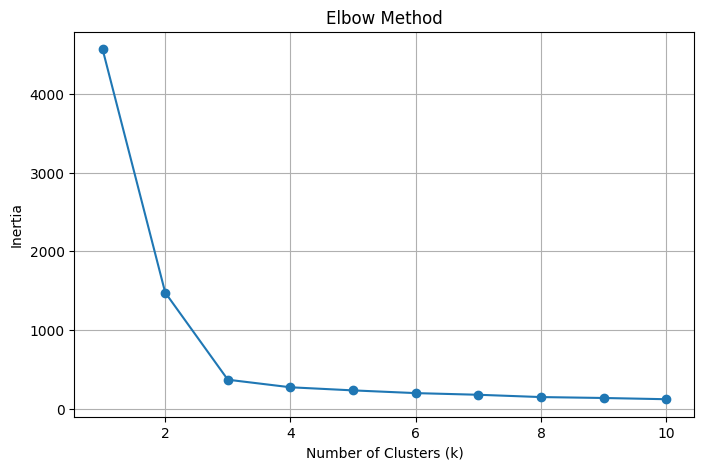

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

# Loop through k=1 to k=10
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# Step 3: Apply K-Means with Optimal k

Fit the K-Means model with the optimal number of clusters and assign cluster labels to each customer.

In [3]:
# Replace '3' with the optimal k you found from the Elbow plot!
k_optimal = 3 

# Initialize and fit the model
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42)
df['cluster'] = kmeans_final.fit_predict(X)

# Get the coordinates of the cluster centers (centroids)
centroids = kmeans_final.cluster_centers_

# See the first few results with their new cluster labels
print(df.head())

   customer_id  action_scifi_hours_per_week  romance_drama_hours_per_week  \
0            1                     8.229288                      1.617055   
1            2                     8.604848                      3.636356   
2            3                     8.750528                      0.496426   
3            4                     7.574800                      1.988591   
4            5                     9.067144                      2.760218   

   cluster  
0        2  
1        2  
2        2  
3        2  
4        2  


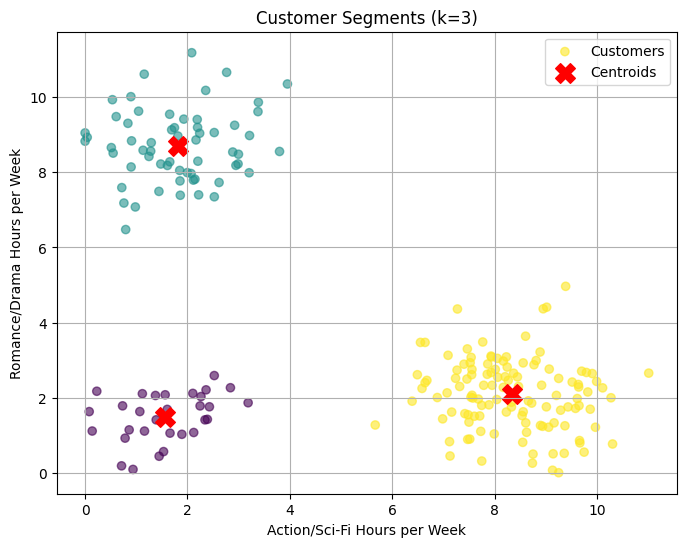

In [4]:
plt.figure(figsize=(8, 6))

# Plot the customer data, colored by cluster
plt.scatter(df['action_scifi_hours_per_week'], 
            df['romance_drama_hours_per_week'], 
            c=df['cluster'], 
            cmap='viridis', 
            alpha=0.6, 
            label='Customers')

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], 
            s=200, c='red', marker='X', label='Centroids')

plt.xlabel('Action/Sci-Fi Hours per Week')
plt.ylabel('Romance/Drama Hours per Week')
plt.title(f'Customer Segments (k={k_optimal})')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Calculate cluster statistics
cluster_summary = []
for i in range(k_optimal):
    cluster_points = X[df['cluster'] == i]
    mean_action = cluster_points.iloc[:, 0].mean()
    mean_romance = cluster_points.iloc[:, 1].mean()
    count = len(cluster_points)
    cluster_summary.append((i, count, mean_action, mean_romance))

print("Cluster | #Customers | Mean Action/Sci-Fi | Mean Romance/Drama")
for i, count, ma, mr in cluster_summary:
    print(f"{i:7d} | {count:10d} | {ma:17.2f} | {mr:18.2f}")

Cluster | #Customers | Mean Action/Sci-Fi | Mean Romance/Drama
      0 |         30 |              1.57 |               1.49
      1 |         60 |              1.81 |               8.70
      2 |        120 |              8.34 |               2.09


# Step 4: The Analysis (Report)

## Summary
**Chosen k:** 3

## Cluster Descriptions and Recommendations

### Cluster 0: The "Action/Sci-Fi Buffs"
**Description:** These customers watch a lot of Action/Sci-Fi content (high hours on the X-axis) but very little Romance/Drama. They are genre-focused users who clearly prefer high-intensity, plot-driven entertainment.

**Recommendation:** Target them with ads for new superhero movies, sci-fi series premieres, and action blockbusters. Offer exclusive early access to Marvel, Star Wars, or sci-fi channel content. Push notifications about new action releases would keep them engaged.

---

### Cluster 1: The "Romance/Drama Enthusiasts"
**Description:** These users are the opposite of Cluster 0—they consume high amounts of Romance/Drama content (high on the Y-axis) but minimal Action/Sci-Fi. They prefer character-driven, emotional storytelling.

**Recommendation:** Promote romantic comedies, drama series, and heartfelt movie collections. Offer personalized playlists like "Top Romance Picks" or "Binge-Worthy Dramas." Send notifications about new romance releases or Valentine's Day specials.

---

### Cluster 2: The "Low Engagement / At-Risk Users"
**Description:** These customers are near the origin (0,0)—they watch very little of both genres. They represent low-usage subscribers who are at high risk of churning (cancelling their subscription).

**Recommendation:** Launch re-engagement campaigns targeting this group. Offer a "We miss you!" discount or free trial extension. Send curated "Trending Now" or "Top Picks for You" lists to spark their interest. Consider a survey to understand why they're not watching and what content might bring them back.